# STTP-Net exp05 — EfficientNet-B4 + CLAHE + Focal+EBS Loss

**Changes from exp04:**
- Encoder: ResNet-50 → EfficientNet-B4 (stronger dermoscopy features)
- Preprocessing: CLAHE added before augmentation
- Loss: EBS → Focal+EBS combined (targets hard mel samples)
- Augmentation: recalibrated — bkl/akiec/df get dedicated boost
- Epochs: 40 Phase1 + 10 Phase2 = 50 total

**Target:** mel recall > 0.80, bkl recall > 0.85, balanced acc > 0.87

---
**Always: Restart Kernel → Run All Cells. Never run cells individually.**

## 0. Install (run once)

In [ ]:
# !pip install torch torchvision --index-url https://download.pytorch.org/whl/cu128
# !pip install timm pandas numpy scikit-learn matplotlib seaborn albumentations tqdm opencv-python

## 1. Imports + Paths + Config

In [1]:
import os, random, warnings, json, copy
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from PIL import Image
from collections import Counter
from matplotlib.patches import Patch

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms, models
import timm

import albumentations as A
from albumentations.pytorch import ToTensorV2

from sklearn.metrics import (classification_report, confusion_matrix,
                              balanced_accuracy_score, roc_auc_score)
from sklearn.preprocessing import label_binarize
from tqdm import tqdm

# ── Seed ──────────────────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = True   # faster cuDNN kernel selection

# ── PATHS  <--- UPDATE THIS ───────────────────────────────────────────────────
BASE_DIR  = r'D:\class imbalance\date-16'   # <-- your path

DATA_DIR  = os.path.join(BASE_DIR, 'data')
RAW_DIR   = os.path.join(DATA_DIR, 'raw')
IMAGE_DIR = os.path.join(RAW_DIR,  'images')
META_PATH = os.path.join(RAW_DIR,  'metadata.csv')
SPLIT_DIR = os.path.join(DATA_DIR, 'splits')
TRAIN_CSV = os.path.join(SPLIT_DIR, 'train.csv')
VAL_CSV   = os.path.join(SPLIT_DIR, 'val.csv')
TEST_CSV  = os.path.join(SPLIT_DIR, 'test.csv')
CKPT_DIR  = os.path.join(BASE_DIR,  'checkpoints')
os.makedirs(CKPT_DIR, exist_ok=True)

# ── Hyperparameters ───────────────────────────────────────────────────────────
IMG_SIZE      = 224
BATCH_SIZE    = 16
NUM_WORKERS   = 2   # was 0 — parallel image loading (safe in Jupyter)
ENCODER_DIM   = 512
LATENT_DIM    = 128
NUM_CLASSES   = 7
LR            = 3e-4
WEIGHT_DECAY  = 1e-4
EPOCHS_PHASE1 = 40    # more Phase1 for mel
EPOCHS_PHASE2 = 10
TEMPERATURE   = 0.07
FOCAL_GAMMA   = 2.0   # focal loss focusing parameter
FOCAL_ALPHA   = 0.25  # focal loss balance parameter
DEVICE        = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ── Class metadata ────────────────────────────────────────────────────────────
CLASS_NAMES = ['nv', 'mel', 'bkl', 'bcc', 'akiec', 'vasc', 'df']
LABEL2IDX   = {c: i for i, c in enumerate(CLASS_NAMES)}
IDX2LABEL   = {i: c for c, i in LABEL2IDX.items()}
HEAD_THRESH = 1000
TAIL_THRESH = 500
COLORS      = {'head': '#2ecc71', 'median': '#f39c12', 'tail': '#e74c3c'}
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# ── Sanity check ──────────────────────────────────────────────────────────────
print(f'Device       : {DEVICE}')
print(f'BASE_DIR     : {BASE_DIR}')
print(f'metadata.csv : {os.path.exists(META_PATH)}')
print(f'train.csv    : {os.path.exists(TRAIN_CSV)}')
print(f'images dir   : {os.path.exists(IMAGE_DIR)}')
assert os.path.exists(META_PATH), 'metadata.csv not found — check BASE_DIR'
print('All paths OK.')

Device       : cuda
BASE_DIR     : D:\class imbalance\date-16
metadata.csv : True
train.csv    : True
images dir   : True
All paths OK.


## 2. Load Data & EDA

In [2]:
def load_splits():
    if os.path.exists(TRAIN_CSV):
        print('Loading existing split CSVs ...')
        tr = pd.read_csv(TRAIN_CSV)
        va = pd.read_csv(VAL_CSV)
        te = pd.read_csv(TEST_CSV)
    else:
        print('No splits found — creating from metadata.csv ...')
        from sklearn.model_selection import train_test_split
        meta = pd.read_csv(META_PATH)
        tr, tmp = train_test_split(meta, test_size=0.30, stratify=meta['dx'], random_state=SEED)
        va, te  = train_test_split(tmp,  test_size=0.50, stratify=tmp['dx'],  random_state=SEED)
        os.makedirs(SPLIT_DIR, exist_ok=True)
        tr.to_csv(TRAIN_CSV, index=False)
        va.to_csv(VAL_CSV,   index=False)
        te.to_csv(TEST_CSV,  index=False)
    for df in [tr, va, te]:
        if 'label_idx' not in df.columns:
            df['label_idx'] = df['dx'].map(LABEL2IDX)
    print(f'train={len(tr)}, val={len(va)}, test={len(te)}')
    return tr, va, te

train_df, val_df, test_df = load_splits()

Loading existing split CSVs ...
train=8012, val=1001, test=1002


Class groups:
  nv      :  5364  [head]
  mel     :   890  [median]
  bkl     :   879  [median]
  bcc     :   411  [tail]
  akiec   :   262  [tail]
  vasc    :   114  [tail]
  df      :    92  [tail]


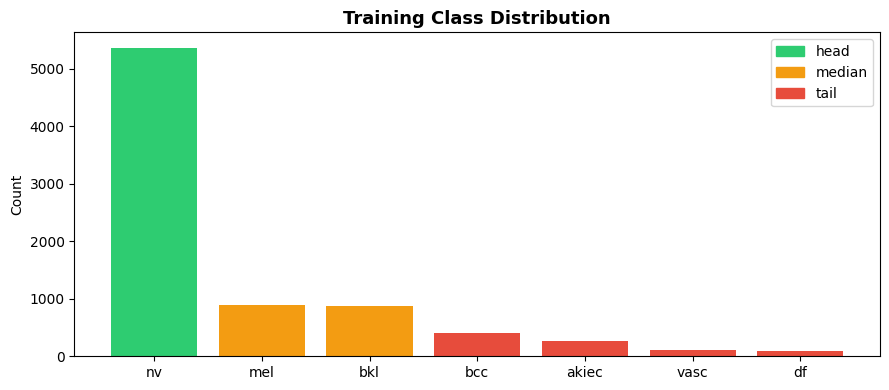

In [3]:
class_counts = Counter(train_df['dx'])

def assign_group(cls):
    n = class_counts[cls]
    if n > HEAD_THRESH: return 'head'
    if n < TAIL_THRESH: return 'tail'
    return 'median'

CLASS_GROUPS   = {c: assign_group(c) for c in CLASS_NAMES}
TAIL_CLASSES   = [c for c, g in CLASS_GROUPS.items() if g == 'tail']
MEDIAN_CLASSES = [c for c, g in CLASS_GROUPS.items() if g == 'median']
HEAD_CLASSES   = [c for c, g in CLASS_GROUPS.items() if g == 'head']

print('Class groups:')
for c in CLASS_NAMES:
    print(f'  {c:8s}: {class_counts[c]:5d}  [{CLASS_GROUPS[c]}]')

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(CLASS_NAMES, [class_counts[c] for c in CLASS_NAMES],
       color=[COLORS[CLASS_GROUPS[c]] for c in CLASS_NAMES])
ax.set_title('Training Class Distribution', fontsize=13, fontweight='bold')
ax.set_ylabel('Count')
ax.legend(handles=[Patch(color=v, label=k) for k, v in COLORS.items()])
plt.tight_layout(); plt.show()

## 3. CLAHE Preprocessing + Augmentation + Dataset

In [4]:
# ── CLAHE preprocessing ────────────────────────────────────────────────────────
# Contrast Limited Adaptive Histogram Equalization
# Standard dermoscopy preprocessing — enhances local contrast,
# makes pigment networks and borders more visible.
# Applied BEFORE augmentation on raw PIL image.
def apply_clahe(pil_img, clip_limit=2.0, tile_grid=(8, 8)):
    img_np  = np.array(pil_img)                        # (H, W, 3) uint8
    lab     = cv2.cvtColor(img_np, cv2.COLOR_RGB2LAB)  # convert to LAB
    l, a, b = cv2.split(lab)
    clahe   = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid)
    l_eq    = clahe.apply(l)                           # equalize only L channel
    lab_eq  = cv2.merge([l_eq, a, b])
    img_eq  = cv2.cvtColor(lab_eq, cv2.COLOR_LAB2RGB)
    return Image.fromarray(img_eq)

# ── Albumentations wrapper ─────────────────────────────────────────────────────
class AlbumentationsTransform:
    def __init__(self, transform):
        self.transform = transform
    def __call__(self, img):
        return self.transform(image=np.array(img))['image']

# ── Train augmentation — head classes ──────────────────────────────────────────
train_aug = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.Rotate(limit=25, p=0.6),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.05, rotate_limit=0, p=0.4),
    A.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, hue=0.02, p=0.6),
    A.RandomGamma(gamma_limit=(90, 110), p=0.3),
    A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ToTensorV2(),
])

# ── Tail augmentation — median + tail classes ──────────────────────────────────
# Slightly stronger rotation and color — still medically safe
# Recalibrated from exp04: bkl/akiec/df get targeted boost
tail_aug = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.7),
    A.Rotate(limit=30, p=0.7),          # reduced from 35 to avoid over-rotation
    A.ShiftScaleRotate(shift_limit=0.06, scale_limit=0.06, rotate_limit=0, p=0.5),
    A.ColorJitter(brightness=0.12, contrast=0.12, saturation=0.12, hue=0.02, p=0.7),
    A.RandomGamma(gamma_limit=(88, 112), p=0.4),
    A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ToTensorV2(),
])

# ── Eval transform ─────────────────────────────────────────────────────────────
eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

train_transform = AlbumentationsTransform(train_aug)
tail_transform  = AlbumentationsTransform(tail_aug)

# ── Dataset with CLAHE + class-conditional augmentation ───────────────────────
class HAMDataset(Dataset):
    def __init__(self, df, transform=None, tail_transform=None, use_clahe=False):
        self.df             = df.reset_index(drop=True)
        self.transform      = transform
        self.tail_transform = tail_transform
        self.use_clahe      = use_clahe

    def _path(self, image_id):
        for ext in ('.jpg', '.jpeg', '.png'):
            p = os.path.join(IMAGE_DIR, image_id + ext)
            if os.path.exists(p): return p
        raise FileNotFoundError(f'{image_id} not found in {IMAGE_DIR}')

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        img   = Image.open(self._path(row['image_id'])).convert('RGB')
        label = int(row['label_idx'])
        cls   = IDX2LABEL[label]

        # Step 1: CLAHE preprocessing (before augmentation)
        if self.use_clahe:
            img = apply_clahe(img)

        # Step 2: Class-conditional augmentation
        if self.tail_transform and CLASS_GROUPS.get(cls) in ('tail', 'median'):
            img = self.tail_transform(img)
        elif self.transform:
            img = self.transform(img)
        return img, label

# Train uses CLAHE, val/test use CLAHE for consistency
train_ds = HAMDataset(train_df, transform=train_transform,
                      tail_transform=tail_transform, use_clahe=True)
val_ds   = HAMDataset(val_df,   transform=eval_transform, use_clahe=True)
test_ds  = HAMDataset(test_df,  transform=eval_transform, use_clahe=True)
print(f'Datasets: train={len(train_ds)}, val={len(val_ds)}, test={len(test_ds)}')

Datasets: train=8012, val=1001, test=1002


## 4. Three Samplers

In [5]:
def instance_sampler(df):
    return WeightedRandomSampler(torch.ones(len(df)), len(df), replacement=True)

def median_sampler(df):
    counts   = df['dx'].value_counts().to_dict()
    median_n = sorted(counts.values())[len(counts)//2]
    w = torch.tensor(np.clip(median_n / df['dx'].map(counts).values, 1.0, 5.0), dtype=torch.float)
    return WeightedRandomSampler(w, len(df), replacement=True)

def reverse_sampler(df):
    counts = df['dx'].value_counts().to_dict()
    freq   = df['dx'].map(counts).values
    w      = 1.0 / freq; w = w / w.sum() * len(w)
    return WeightedRandomSampler(torch.tensor(w, dtype=torch.float), len(df), replacement=True)

def make_loader(ds, sampler, **kw):
    return DataLoader(ds, batch_size=BATCH_SIZE, sampler=sampler,
                      num_workers=NUM_WORKERS, pin_memory=True, **kw)

loader_instance = make_loader(train_ds, instance_sampler(train_df))
loader_median   = make_loader(train_ds, median_sampler(train_df))
loader_reverse  = make_loader(train_ds, reverse_sampler(train_df))
val_loader  = DataLoader(val_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)
print('Samplers and loaders ready.')

Samplers and loaders ready.


## 5. Encoder — EfficientNet-B4 (upgraded from ResNet-50)

In [6]:
# ── EfficientNet-B4 Encoder ────────────────────────────────────────────────────
# Why EfficientNet-B4 over ResNet-50:
#   - Compound scaling: balances depth, width, resolution simultaneously
#   - Better feature extraction per parameter on medical images
#   - Proven on dermoscopy in literature
#   - Lighter than Swin Transformer, stronger than ResNet-50
#   - in_features = 1792 (vs 2048 for ResNet-50)
class Encoder(nn.Module):
    def __init__(self, out_dim=ENCODER_DIM):
        super().__init__()
        # EfficientNet-B4 pretrained on ImageNet
        bb        = timm.create_model('efficientnet_b4', pretrained=True, num_classes=0)
        in_f      = bb.num_features   # 1792
        self.backbone = bb
        self.proj = nn.Sequential(
            nn.Linear(in_f, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(1024, out_dim),
        )

    def forward(self, x):
        return self.proj(self.backbone(x))

# Shape test
enc = Encoder().to(DEVICE)
with torch.no_grad():
    out = enc(torch.randn(2, 3, IMG_SIZE, IMG_SIZE).to(DEVICE))
print(f'EfficientNet-B4 encoder output: {out.shape}')  # (2, 512)

model.safetensors:   0%|          | 0.00/77.9M [00:00<?, ?B/s]

EfficientNet-B4 encoder output: torch.Size([2, 512])


## 6. CVAE

In [7]:
class CVAE(nn.Module):
    def __init__(self, feat_dim=ENCODER_DIM, lat_dim=LATENT_DIM, nc=NUM_CLASSES):
        super().__init__()
        self.lat_dim = lat_dim; self.nc = nc
        self.enc1    = nn.Linear(feat_dim + nc, 256)
        self.mu      = nn.Linear(256, lat_dim)
        self.logv    = nn.Linear(256, lat_dim)
        self.dec1    = nn.Linear(lat_dim + nc, 256)
        self.dec_out = nn.Linear(256, feat_dim)

    def encode(self, f, y):
        h = F.relu(self.enc1(torch.cat([f, y], -1)))
        return self.mu(h), self.logv(h)

    def decode(self, z, y):
        return self.dec_out(F.relu(self.dec1(torch.cat([z, y], -1))))

    def forward(self, f, labels):
        y = F.one_hot(labels, self.nc).float()
        mu, lv = self.encode(f, y)
        z = mu + torch.randn_like(mu) * torch.exp(0.5 * lv)
        return self.decode(z, y), mu, lv, z

def cvae_loss(recon, orig, mu, lv, beta=1.0):
    r = F.mse_loss(recon, orig)
    k = -0.5 * torch.mean(1 + lv - mu.pow(2) - lv.exp())
    return r + beta * k

print('CVAE ready.')

CVAE ready.


## 7. Supervised Contrastive Loss

In [8]:
class SupConLoss(nn.Module):
    def __init__(self, temp=TEMPERATURE):
        super().__init__(); self.temp = temp

    def forward(self, features, labels):
        B = features.shape[0]
        f = F.normalize(features.view(2*B, -1), dim=1)
        labels = labels.repeat(2)
        mask = torch.eq(labels.unsqueeze(0), labels.unsqueeze(1)).float().to(f.device)
        eye  = torch.eye(2*B, device=f.device)
        mask = mask * (1 - eye)
        logits = torch.mm(f, f.T) / self.temp
        exp_l  = torch.exp(logits) * (1 - eye)
        log_p  = logits - torch.log(exp_l.sum(1, keepdim=True) + 1e-9)
        return -(mask * log_p).sum(1).div(mask.sum(1) + 1e-9).mean()

print('SupConLoss ready.')

SupConLoss ready.


## 8. HybridMix (CMeO + Mixup)

In [9]:
def cmeo_cutmix(a, b, la, lb, alpha=1.0):
    lam = np.random.beta(alpha, alpha)
    _, _, H, W = a.shape
    cr = np.sqrt(1 - lam)
    cw, ch = int(W*cr), int(H*cr)
    cx, cy = np.random.randint(W), np.random.randint(H)
    x1,x2 = np.clip(cx-cw//2,0,W), np.clip(cx+cw//2,0,W)
    y1,y2 = np.clip(cy-ch//2,0,H), np.clip(cy+ch//2,0,H)
    m = a.clone(); m[:,:,y1:y2,x1:x2] = b[:,:,y1:y2,x1:x2]
    return m, la, lb, 1-(x2-x1)*(y2-y1)/(H*W)

def do_mixup(a, b, la, lb, alpha=0.4):
    lam = np.random.beta(alpha, alpha)
    return lam*a + (1-lam)*b, la, lb, lam

def hybrid_mix(imgs, labels):
    B = imgs.size(0)
    perm = torch.randperm(B)
    ib, lb = imgs[perm], labels[perm]
    is_tail = torch.tensor([IDX2LABEL[l.item()] in TAIL_CLASSES for l in labels])
    mixed = torch.zeros_like(imgs); lam_v = torch.ones(B)
    if is_tail.sum() > 0:
        m,_,_,l = do_mixup(imgs[is_tail], ib[is_tail], labels[is_tail], lb[is_tail])
        mixed[is_tail] = m; lam_v[is_tail] = l
    ih = ~is_tail
    if ih.sum() > 0:
        m,_,_,l = cmeo_cutmix(imgs[ih], ib[ih], labels[ih], lb[ih])
        mixed[ih] = m; lam_v[ih] = l
    return mixed, labels, lb, lam_v

print('HybridMix ready.')

HybridMix ready.


## 9. STTP-Net (Dual-Head — EfficientNet-B4 backbone)

In [10]:
class Head(nn.Module):
    def __init__(self, in_d, nc, drop=0.4):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Dropout(drop), nn.Linear(in_d,256), nn.ReLU(inplace=True),
            nn.Dropout(drop*0.5), nn.Linear(256, nc))
    def forward(self, x): return self.fc(x)

class STTPNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = Encoder(ENCODER_DIM)
        self.cvae    = CVAE(ENCODER_DIM, LATENT_DIM, NUM_CLASSES)
        self.head1   = Head(ENCODER_DIM, NUM_CLASSES)   # head + median
        self.head2   = Head(ENCODER_DIM, NUM_CLASSES)   # tail
        self.sc_proj = nn.Sequential(
            nn.Linear(ENCODER_DIM,128), nn.ReLU(inplace=True), nn.Linear(128,128))

    def forward(self, x, labels=None, use_cvae=True):
        f  = self.encoder(x)
        cv = self.cvae(f, labels) if (use_cvae and labels is not None) else None
        return self.head1(f), self.head2(f), self.sc_proj(f), f, cv

    def fused_logits(self, x):
        f  = self.encoder(x)
        l1 = self.head1(f); l2 = self.head2(f)
        return (l1/self.head1.fc[-1].weight.norm() +
                l2/self.head2.fc[-1].weight.norm()) * 0.5

model = STTPNet().to(DEVICE)
print(f'Parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')

Parameters: 20,625,238


## 10. Focal + EBS Combined Loss

In [11]:
# ── Effective Balanced Softmax Loss ───────────────────────────────────────────
class EBSLoss(nn.Module):
    def __init__(self, counts):
        super().__init__()
        n = torch.tensor([float(counts.get(c,1)) for c in CLASS_NAMES])
        self.register_buffer('log_n', torch.log(n))
    def forward(self, logits, labels):
        return F.cross_entropy(logits + self.log_n.to(logits.device), labels)

# ── Focal Loss ────────────────────────────────────────────────────────────────
# Focuses training on hard, misclassified samples
# (1-pt)^gamma downweights easy examples
# Specifically helps mel which is visually similar to nv
class FocalLoss(nn.Module):
    def __init__(self, gamma=FOCAL_GAMMA, alpha=FOCAL_ALPHA):
        super().__init__()
        self.gamma = gamma
        self.alpha = alpha

    def forward(self, logits, labels):
        ce_loss = F.cross_entropy(logits, labels, reduction='none')
        pt      = torch.exp(-ce_loss)                        # prob of correct class
        focal   = self.alpha * (1 - pt) ** self.gamma * ce_loss
        return focal.mean()

# ── Combined Focal + EBS Loss ─────────────────────────────────────────────────
class FocalEBSLoss(nn.Module):
    """
    Combines EBS (handles class frequency imbalance) with
    Focal Loss (handles hard sample difficulty).
    EBS adjusts logits with log-frequency prior.
    Focal then focuses on hard examples within that adjusted space.
    w_focal controls the balance between the two.
    """
    def __init__(self, counts, gamma=FOCAL_GAMMA, alpha=FOCAL_ALPHA, w_focal=0.5):
        super().__init__()
        self.ebs     = EBSLoss(counts)
        self.focal   = FocalLoss(gamma, alpha)
        self.w_focal = w_focal

    def forward(self, logits, labels):
        return ((1 - self.w_focal) * self.ebs(logits, labels) +
                self.w_focal       * self.focal(logits, labels))

def mixed_ce(logits, la, lb, lam, loss_fn):
    if isinstance(lam, torch.Tensor):
        lam = lam.to(logits.device)
        return (lam * F.cross_entropy(logits, la.to(logits.device), reduction='none')
              + (1-lam) * F.cross_entropy(logits, lb.to(logits.device), reduction='none')).mean()
    return lam*loss_fn(logits,la) + (1-lam)*loss_fn(logits,lb)

ebs      = FocalEBSLoss(class_counts).to(DEVICE)   # combined loss
sup_con  = SupConLoss().to(DEVICE)
print('FocalEBSLoss and SupConLoss ready.')

FocalEBSLoss and SupConLoss ready.


## 11. Train & Evaluate Functions

In [12]:
def train_epoch(model, opt, use_hm=True):
    model.train()
    total, n = 0.0, 0
    it_rev = iter(loader_reverse)

    for (imgs_i, lbl_i), (imgs_m, lbl_m) in zip(
            tqdm(loader_instance, desc='  train', leave=False), loader_median):
        try:    imgs_r, lbl_r = next(it_rev)
        except: it_rev = iter(loader_reverse); imgs_r, lbl_r = next(it_rev)

        imgs_i, lbl_i = imgs_i.to(DEVICE), lbl_i.to(DEVICE)
        imgs_m, lbl_m = imgs_m.to(DEVICE), lbl_m.to(DEVICE)
        imgs_r, lbl_r = imgs_r.to(DEVICE), lbl_r.to(DEVICE)
        opt.zero_grad()

        # ── Head-1: instance + median ─────────────────────────────────────────
        imgs_hm = torch.cat([imgs_i, imgs_m])
        lbl_hm  = torch.cat([lbl_i,  lbl_m])
        if use_hm:
            imgs_hm, la, lb, lam = hybrid_mix(imgs_hm, lbl_hm)
            imgs_hm=imgs_hm.to(DEVICE); la=la.to(DEVICE); lb=lb.to(DEVICE)
        else:
            la, lb, lam = lbl_hm, lbl_hm, 1.0

        # Single forward pass — proj_hm reused for SupCon (eliminates 3rd pass)
        l1, _, proj_hm, f_hm, cv = model(imgs_hm, lbl_hm, use_cvae=True)
        loss_h1 = mixed_ce(l1, la, lb, lam, ebs) if use_hm else ebs(l1, lbl_hm)

        loss_cv = torch.tensor(0., device=DEVICE)
        if cv is not None:
            recon, mu, lv, _ = cv
            loss_cv = cvae_loss(recon, f_hm.detach(), mu, lv)

        # ── SupCon — slice instance portion from proj_hm (no extra forward pass) ──
        # imgs_hm = cat([imgs_i, imgs_m]), so first B_i rows correspond to instance batch
        B_i = imgs_i.shape[0]
        proj_sc = proj_hm[:B_i]
        loss_sc = sup_con(proj_sc.unsqueeze(1).repeat(1, 2, 1), lbl_i)

        # ── Head-2: reverse / tail-heavy ──────────────────────────────────────
        if use_hm:
            imgs_r2, la_r, lb_r, lam_r = hybrid_mix(imgs_r, lbl_r)
            imgs_r2=imgs_r2.to(DEVICE); la_r=la_r.to(DEVICE); lb_r=lb_r.to(DEVICE)
        else:
            imgs_r2, la_r, lb_r, lam_r = imgs_r, lbl_r, lbl_r, 1.0

        _, l2, _, _, _ = model(imgs_r2, lbl_r, use_cvae=False)
        loss_h2 = mixed_ce(l2, la_r, lb_r, lam_r, ebs) if use_hm else ebs(l2, lbl_r)

        loss = loss_h1 + loss_h2 + 0.3*loss_sc + 0.2*loss_cv
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 2.0)
        opt.step()
        total += loss.item(); n += 1

    return total / max(n, 1)



@torch.no_grad()
def evaluate(model, loader):
    """Standard evaluation — used during training loop."""
    model.eval()
    preds, labels, probs = [], [], []
    for imgs, lbl in loader:
        p = F.softmax(model.fused_logits(imgs.to(DEVICE)), -1).cpu()
        preds.append(p.argmax(-1)); labels.append(lbl); probs.append(p)
    preds  = torch.cat(preds).numpy()
    labels = torch.cat(labels).numpy()
    probs  = torch.cat(probs).numpy()
    return ((preds==labels).mean(),
            balanced_accuracy_score(labels, preds),
            preds, labels, probs)


@torch.no_grad()
def evaluate_tta(model, loader, n_tta=5):
    """TTA evaluation — averages n_tta passes. Use at final test only."""
    model.eval()
    tta_transform = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomVerticalFlip(p=0.5),
        transforms.RandomRotation(15),
        transforms.ColorJitter(brightness=0.1, contrast=0.1,
                               saturation=0.1, hue=0.02),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ])
    preds, labels, probs = [], [], []
    for imgs, lbl in tqdm(loader, desc='  TTA eval', leave=False):
        B = imgs.size(0)
        batch_probs = torch.zeros(B, NUM_CLASSES)
        # Pass 1: clean
        batch_probs += F.softmax(model.fused_logits(imgs.to(DEVICE)), -1).cpu()
        # Passes 2-n_tta: augmented
        for _ in range(n_tta - 1):
            aug_imgs = []
            for img_tensor in imgs:
                img_np  = img_tensor.permute(1,2,0).numpy()
                img_np  = (img_np * np.array(IMAGENET_STD) + np.array(IMAGENET_MEAN))
                img_np  = np.clip(img_np * 255, 0, 255).astype(np.uint8)
                img_pil = Image.fromarray(img_np)
                # Apply CLAHE on TTA images too for consistency
                img_pil = apply_clahe(img_pil)
                aug_imgs.append(tta_transform(img_pil))
            aug_batch    = torch.stack(aug_imgs).to(DEVICE)
            batch_probs += F.softmax(model.fused_logits(aug_batch), -1).cpu()
        batch_probs /= n_tta
        preds.append(batch_probs.argmax(-1))
        labels.append(lbl)
        probs.append(batch_probs)
    preds  = torch.cat(preds).numpy()
    labels = torch.cat(labels).numpy()
    probs  = torch.cat(probs).numpy()
    return ((preds==labels).mean(),
            balanced_accuracy_score(labels, preds),
            preds, labels, probs)


print('Train / evaluate / evaluate_tta — all ready.')

Train / evaluate / evaluate_tta — all ready.


## 12. Two-Phase Training Loop

In [ ]:
# ── Experiment folder ─────────────────────────────────────────────────────────
EXP_NAME = 'exp05_efficientnetb4_clahe_focal'
EXP_DIR  = os.path.join(BASE_DIR, 'experiments', EXP_NAME)
os.makedirs(EXP_DIR, exist_ok=True)

config = {
    'exp_name':      EXP_NAME,
    'epochs_phase1': EPOCHS_PHASE1,
    'epochs_phase2': EPOCHS_PHASE2,
    'batch_size':    BATCH_SIZE,
    'lr':            LR,
    'encoder':       'EfficientNet-B4 (timm, ImageNet pretrained)',
    'encoder_dim':   ENCODER_DIM,
    'latent_dim':    LATENT_DIM,
    'loss':          f'FocalEBS (w_focal=0.5, gamma={FOCAL_GAMMA}, alpha={FOCAL_ALPHA})',
    'clahe':         'clip_limit=2.0, tile_grid=(8,8)',
    'augmentation':  'safe dermoscopy aug + class-conditional tail_aug (recalibrated)',
    'notes':         'exp05: EfficientNet-B4 + CLAHE + Focal+EBS. Target: mel>0.80, bkl>0.85',
}
with open(os.path.join(EXP_DIR, 'config.json'), 'w') as f:
    json.dump(config, f, indent=2)

print(f'Experiment : {EXP_NAME}')
print(f'Saving to  : {EXP_DIR}')

# ── Optimizer & scheduler ─────────────────────────────────────────────────────
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=EPOCHS_PHASE1+EPOCHS_PHASE2, eta_min=1e-6)

history  = {'epoch':[], 'loss':[], 'val_acc':[], 'val_bal':[], 'phase':[]}
best_bal  = 0.0
best_ckpt = os.path.join(EXP_DIR, 'best_model.pt')

# ── Training loop ─────────────────────────────────────────────────────────────
torch.cuda.empty_cache()
for epoch in range(1, EPOCHS_PHASE1+EPOCHS_PHASE2+1):
    phase  = 'HybridMix' if epoch <= EPOCHS_PHASE1 else 'Boundary Refinement'
    use_hm = epoch <= EPOCHS_PHASE1
    print(f'\nEpoch {epoch}/{EPOCHS_PHASE1+EPOCHS_PHASE2}  [{phase}]')

    loss = train_epoch(model, optimizer, use_hm)
    acc, bal, _, _, _ = evaluate(model, val_loader)
    scheduler.step()

    history['epoch'].append(epoch); history['loss'].append(loss)
    history['val_acc'].append(acc); history['val_bal'].append(bal)
    history['phase'].append(phase)
    print(f'  Loss={loss:.4f}  Val Acc={acc:.4f}  Val Balanced={bal:.4f}')

    if bal > best_bal:
        best_bal = bal
        torch.save(model.state_dict(), best_ckpt)
        print(f'  [best saved  bal={bal:.4f}]')

print(f'\nDone. Best val balanced acc: {best_bal:.4f}')

Experiment : exp05_efficientnetb4_clahe_focal
Saving to  : D:\class imbalance\date-16\experiments\exp05_efficientnetb4_clahe_focal

Epoch 1/50  [HybridMix]


  train:  22%|██▏       | 109/501 [30:14<1:50:30, 16.92s/it]

## 13. Training Curves

In [ ]:
p2 = next((e for e,p in zip(history['epoch'],history['phase']) if p=='Boundary Refinement'), None)
fig, axes = plt.subplots(1,2,figsize=(14,5))
axes[0].plot(history['epoch'], history['loss'], 'b-o', ms=3)
if p2: axes[0].axvline(p2, color='gray', ls='--', label='Phase 2')
axes[0].set_title('Train Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend()
axes[1].plot(history['epoch'], history['val_acc'], 'g-o',  ms=3, label='Accuracy')
axes[1].plot(history['epoch'], history['val_bal'], 'r--s', ms=3, label='Balanced Acc')
if p2: axes[1].axvline(p2, color='gray', ls='--', label='Phase 2')
axes[1].set_title('Val Metrics'); axes[1].set_xlabel('Epoch'); axes[1].legend()
plt.suptitle(f'STTP-Net {EXP_NAME}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(EXP_DIR, 'training_curves.png'), dpi=150)
plt.show()

## 14. Test Set Evaluation

In [ ]:
model.load_state_dict(torch.load(best_ckpt, map_location=DEVICE))
test_acc, test_bal, test_preds, test_labels, test_probs = evaluate_tta(model, test_loader, n_tta=5)
print(f'Test Accuracy          : {test_acc:.4f}')
print(f'Test Balanced Accuracy : {test_bal:.4f}\n')
print(classification_report(test_labels, test_preds, target_names=CLASS_NAMES, digits=4))

In [ ]:
cm = confusion_matrix(test_labels, test_preds)
fig, axes = plt.subplots(1,2,figsize=(16,6))
for ax, data, title, fmt in zip(axes,
    [cm, cm.astype(float)/cm.sum(1,keepdims=True)],
    ['Counts','Normalised'], ['d','.2f']):
    sns.heatmap(data, annot=True, fmt=fmt, cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
    ax.set_title(f'Confusion Matrix ({title})')
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
plt.tight_layout()
plt.savefig(os.path.join(EXP_DIR, 'confusion_matrix.png'), dpi=150)
plt.show()

In [ ]:
per = {IDX2LABEL[i]: (test_preds[test_labels==i]==i).mean()
       for i in range(NUM_CLASSES) if (test_labels==i).sum()>0}
fig, ax = plt.subplots(figsize=(9,4))
ax.bar(per.keys(), per.values(), color=[COLORS[CLASS_GROUPS[c]] for c in per])
ax.axhline(test_acc, color='black',  ls='--', label=f'Overall ({test_acc:.3f})')
ax.axhline(test_bal, color='purple', ls=':',  label=f'Balanced ({test_bal:.3f})')
ax.set_ylim(0,1.05); ax.set_ylabel('Accuracy')
ax.set_title('Per-Class Accuracy', fontsize=13, fontweight='bold')
ax.legend(handles=[
    Patch(color=v,label=k) for k,v in COLORS.items()
]+[
    plt.Line2D([0],[0],color='black', ls='--',label=f'Overall ({test_acc:.3f})'),
    plt.Line2D([0],[0],color='purple',ls=':' ,label=f'Balanced ({test_bal:.3f})')
])
plt.tight_layout()
plt.savefig(os.path.join(EXP_DIR, 'per_class_acc.png'), dpi=150)
plt.show()

## 15. Macro-AUC

In [ ]:
try:
    auc = roc_auc_score(label_binarize(test_labels, classes=list(range(NUM_CLASSES))),
                        test_probs, multi_class='ovr', average='macro')
    print(f'Macro AUC: {auc:.4f}')
except Exception as e:
    print(f'AUC skipped: {e}')

## 16. Latent Space Visualisation (t-SNE)

In [ ]:
from sklearn.manifold import TSNE

@torch.no_grad()
def get_latents(loader, max_batches=20):
    model.eval()
    fs, ls = [], []
    for i,(imgs,lbl) in enumerate(loader):
        if i >= max_batches: break
        f = model.encoder(imgs.to(DEVICE))
        y = F.one_hot(lbl.to(DEVICE), NUM_CLASSES).float()
        mu,_ = model.cvae.encode(f, y)
        fs.append(mu.cpu().numpy()); ls.append(lbl.numpy())
    return np.concatenate(fs), np.concatenate(ls)

feats, lbls = get_latents(val_loader)
emb = TSNE(n_components=2, perplexity=30, random_state=SEED, max_iter=1000).fit_transform(feats)

fig, ax = plt.subplots(figsize=(9,7))
cmap = plt.get_cmap('tab10')
for i, cls in IDX2LABEL.items():
    m = lbls==i
    ax.scatter(emb[m,0], emb[m,1], label=f'{cls} [{CLASS_GROUPS[cls]}]',
               alpha=0.6, s=10, color=cmap(i))
ax.set_title('CVAE Latent Space — t-SNE (Val)', fontsize=13, fontweight='bold')
ax.legend(markerscale=2, fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(EXP_DIR, 'tsne_latent.png'), dpi=150)
plt.show()

## 17. Single Image Inference

In [ ]:
def predict(image_path):
    model.eval()
    img = Image.open(image_path).convert('RGB')
    img = apply_clahe(img)   # CLAHE before inference
    with torch.no_grad():
        p = F.softmax(model.fused_logits(
            eval_transform(img).unsqueeze(0).to(DEVICE)), -1).squeeze().cpu().numpy()
    res  = {c: float(v) for c,v in zip(CLASS_NAMES, p)}
    pred = max(res, key=res.get)
    fig, axes = plt.subplots(1,2,figsize=(10,4))
    axes[0].imshow(Image.open(image_path)); axes[0].axis('off'); axes[0].set_title('Input')
    axes[1].barh(CLASS_NAMES, [res[c] for c in CLASS_NAMES],
                 color=[COLORS[CLASS_GROUPS[c]] for c in CLASS_NAMES])
    axes[1].set_xlim(0,1)
    axes[1].set_title(f'{pred}  ({res[pred]:.1%})')
    plt.tight_layout(); plt.show()
    return res

# Usage — update path and uncomment:
# predict(r'D:\class imbalance\date-16\data\raw\images\ISIC_0024306.jpg')
print('predict() ready.')

## 18. Save Results Summary

In [ ]:
out = {
    'exp_name':               EXP_NAME,
    'test_accuracy':          round(float(test_acc), 4),
    'test_balanced_accuracy': round(float(test_bal), 4),
    'best_val_balanced_acc':  round(best_bal, 4),
    'class_groups':           CLASS_GROUPS,
    'architecture':           'EfficientNet-B4 + CVAE + SupCon + HybridMix + DualHead + FocalEBS',
    'phases': {
        'phase1': f'{EPOCHS_PHASE1} epochs HybridMix',
        'phase2': f'{EPOCHS_PHASE2} epochs Boundary Refinement'
    },
    'vs_exp01': {
        'exp01_acc': 0.9042, 'exp01_bal': 0.8686,
        'exp04_acc': 0.9072, 'exp04_bal': 0.8561,
        'exp05_acc': round(float(test_acc), 4),
        'exp05_bal': round(float(test_bal), 4),
    }
}
path = os.path.join(EXP_DIR, 'results_summary.json')
with open(path, 'w') as f:
    json.dump(out, f, indent=2)
print('Saved:', path)
print(json.dumps(out, indent=2))